### **Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### **Load And Explore**

In [ ]:
# 1 - Load the dataset
df = pd.read_csv("/content/AI_Human.csv", engine="python", on_bad_lines="skip")
df.to_csv("/content/AI_Human_clean.csv", index=False)
# We used this approach to handle and clean formatting issues in the dataset
# so it can be loaded correctly without parsing errors or inconsistent row structures.

# 2 - Print the first 5 rows
display('first 5 rows:',df.head())

# 3 - Check the shape
print('\nCheck the shape:',df.shape)

# 4 - Check for missing values
print('\nCheck for missing values:',df.isnull().sum())

# 5 - Check class balance
print('\nCheck class balance:',df['generated'].value_counts())
# 0.0 Human
# 1.0 Ai

# The dataset is imbalanced because one class contains more samples than the other.
# So, F1-score was used as the primary evaluation metric instead of accuracy.

'first 5 rows:'

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0



Check the shape: (20961, 2)

Check for missing values: text         0
generated    0
dtype: int64

Check class balance: generated
0.0    16095
1.0     4866
Name: count, dtype: int64


### **Prepare the Data**

In [ ]:
from sklearn.model_selection import train_test_split
# 1 - Identify the axes
X = df['text']
y = df['generated']

# 2 - Dividing the data set into train and test
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.5, random_state=42, stratify=y
)

In [ ]:
"""
Text datasets only: clean the text
"""
import re, nltk
from nltk.corpus import stopwords
# 1 - Download English stop words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 2 - Cleaning function
def clean(text):
 text = text.lower()# Converting text to lowercase letters
 text = re.sub(r'[^a-z\s]', '', text) # Delete any non-English character or distance
 words = [w for w in text.split() if w not in stop_words]
 return ' '.join(words)

#  3 - Applying the cleaning function to the data set
df['clean_text'] = df['text'].apply(clean)

"""
Convert text to numbers with TF-IDF
"""
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000) # 1 - Create a tfidf
X_train = tfidf.fit_transform(X_train) # 2 - Learn vocab on train only and convert training data into numbers
X_test = tfidf.transform(X_test) # 3 - apply to test convert training data into numbers

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### **Train and Compare Models**

Logistic Regression Model

In [ ]:
# Train the Logistic Regression Model
model1=LogisticRegression()
model1.fit(X_train,y_train)

# Logistic Regression Model Prediction
logis_pred=model1.predict(X_test)

Random Forest Model

In [ ]:
# Train the Random Forest Model
model2=RandomForestClassifier()
model2.fit(X_train,y_train)

# Random Forest Model Prediction
rndm_pred=model2.predict(X_test)

KNN Model

In [ ]:
# Train the KNN Model
model3=KNeighborsClassifier()
model3.fit(X_train,y_train)

# KNN Model Prediction
knn_pred=model3.predict(X_test)

Accuracy

In [ ]:
print('Logistic Regression Accuracy:',accuracy_score(y_test,logis_pred))
print('\nRandom Forest Accuracy:',accuracy_score(y_test,rndm_pred))
print('\nKNN Accuracy:',accuracy_score(y_test,knn_pred))

Logistic Regression Accuracy: 0.9866424959450434

Random Forest Accuracy: 0.9829214769583055

KNN Accuracy: 0.967369525808606


Precision

In [ ]:
print('Logistic Regression Precision:',precision_score(y_test,logis_pred))
print('\nRandom Forest Precision:',precision_score(y_test,rndm_pred))
print('\nKNN Precision:',precision_score(y_test,knn_pred))

Logistic Regression Precision: 0.994394135403191

Random Forest Precision: 0.9982316534040672

KNN Precision: 0.9579500657030223


Recall

In [ ]:
print('Logistic Regression Recall:',recall_score(y_test,logis_pred))
print('\nRandom Forest Recall:',recall_score(y_test,rndm_pred))
print('\nKNN Recall:',recall_score(y_test,knn_pred))

Logistic Regression Recall: 0.9478010686395396

Random Forest Recall: 0.928072338676531

KNN Recall: 0.8988902589395807


F1-score

In [ ]:
print('Logistic Regression F1-score:',f1_score(y_test,logis_pred))
print('\nRandom Forest F1-score:',f1_score(y_test,rndm_pred))
print('\nKNN F1-score:',f1_score(y_test,knn_pred))

Logistic Regression F1-score: 0.9705387205387206

Random Forest F1-score: 0.9618743343982961

KNN F1-score: 0.9274809160305344


### **Plot A Confusion Matrix For Each Model**

In [ ]:
cm1=confusion_matrix(y_test,logis_pred)
cm2=confusion_matrix(y_test,rndm_pred)
cm3=confusion_matrix(y_test,knn_pred)

The cmap colors used in this heatmap were inspired by
https://matplotlib.org/stable/users/explain/colors/colormaps.html

<function matplotlib.pyplot.show(close=None, block=None)>

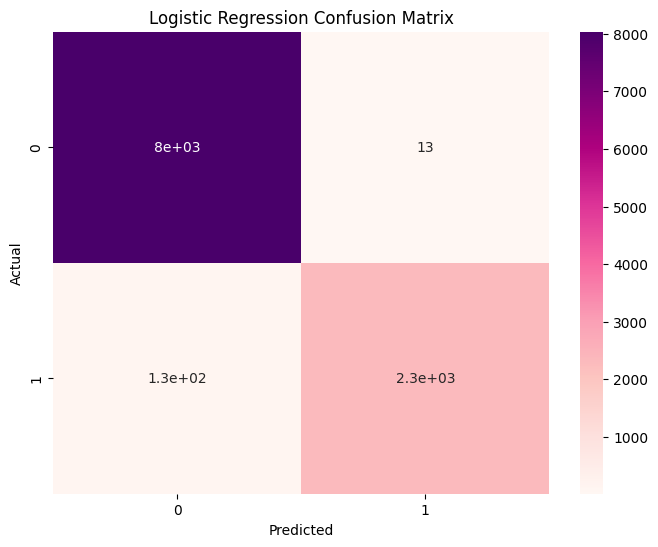

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm1,annot=True,cmap='RdPu')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

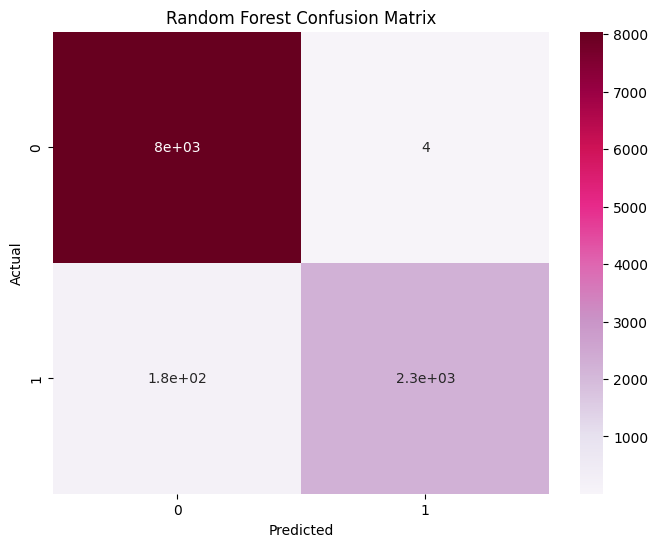

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm2,annot=True,cmap='PuRd')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

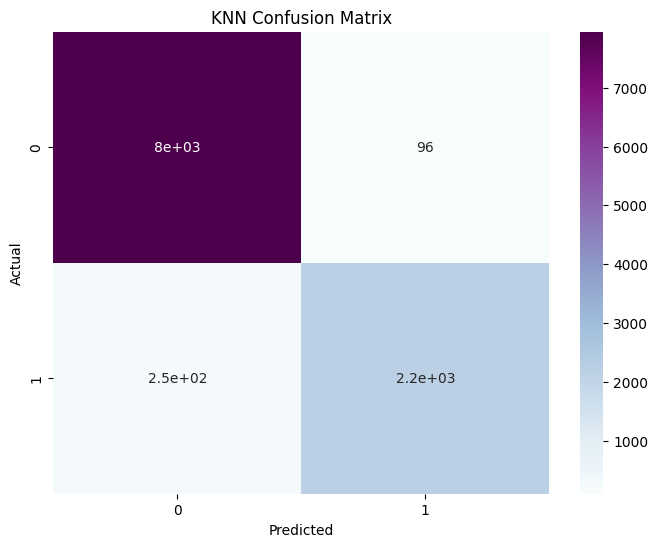

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm3,annot=True,cmap='BuPu')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

In [40]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.9866424959450434,
        "Precision":  0.994394135403191,
        "Recall": 0.9478010686395396,
        "F1-score": 0.9705387205387206
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.9829214769583055,
        "Precision":  0.9982316534040672,
        "Recall": 0.928072338676531,
        "F1-score": 0.9618743343982961
    },
    {
        "Model": "KNN",
        "Accuracy": 0.967369525808606,
        "Precision": 0.9579500657030223,
        "Recall": 0.8988902589395807,
        "F1-score": 0.9274809160305344
    }
]
results_df = pd.DataFrame(results)
print(f"results_df\n{results_df}")

results_df
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.986642   0.994394  0.947801  0.970539
1        Random Forest  0.982921   0.998232  0.928072  0.961874
2                  KNN  0.967370   0.957950  0.898890  0.927481


In [41]:
The_best_model = results_df.loc[results_df["F1-score"].idxmax()]

print(f"The_Best Model:{The_best_model["Model"]}")

The_Best Model:Logistic Regression


### **Neural Network**

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout

In [ ]:
"""first Neural Network"""
model_1 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1, activation="sigmoid"), # One neuron for binary classification
])

#  1 - Assembly of the first model
model_1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#  2 - Training the first model using the original training data
history_1 = model_1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9458 - loss: 0.1681 - val_accuracy: 0.9866 - val_loss: 0.0506
Epoch 2/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9929 - loss: 0.0295 - val_accuracy: 0.9925 - val_loss: 0.0251
Epoch 3/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9985 - loss: 0.0106 - val_accuracy: 0.9938 - val_loss: 0.0174
Epoch 4/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9998 - loss: 0.0048 - val_accuracy: 0.9947 - val_loss: 0.0150
Epoch 5/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.9949 - val_loss: 0.0134
Epoch 6/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9950 - val_loss: 0.0128
Epoch 7/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9954 - val_loss: 0.0119
Epoch 8/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 1.0000 - loss: 7.3466e-04 - val_acc

In [ ]:
"""second Neural Network"""

# 1 - Convert labels to One-Hot Encoding
# Because neural networks calculate that 1 and 0 have a order, we did One-Hot Encoding
y_train_oh = to_categorical(y_train, num_classes=2)
y_test_oh = to_categorical(y_test, num_classes=2)

model_2 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3), # Arrest30% to reduce overfitting
    Dense(2, activation="softmax"), # two neuron for categorical_crossentropy
])

# 2 - Assembly of the second model
model_2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

#  3 - Training the first model using the original training data
history_2 = model_2.fit(X_train, y_train_oh, epochs=10, validation_data=(X_test, y_test_oh))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9366 - loss: 0.1881 - val_accuracy: 0.9860 - val_loss: 0.0561
Epoch 2/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9908 - loss: 0.0418 - val_accuracy: 0.9906 - val_loss: 0.0304
Epoch 3/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9955 - loss: 0.0198 - val_accuracy: 0.9936 - val_loss: 0.0196
Epoch 4/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9986 - loss: 0.0097 - val_accuracy: 0.9940 - val_loss: 0.0168
Epoch 5/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9994 - loss: 0.0051 - val_accuracy: 0.9947 - val_loss: 0.0143
Epoch 6/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9999 - loss: 0.0035 - val_accuracy: 0.9952 - val_loss: 0.0124
Epoch 7/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9999 - loss: 0.0022 - val_accuracy: 0.9949 - val_loss: 0.0126
Epoch 8/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0

### **Plot the training vs. validation loss and accuracy curves**

The training loss and validation loss both decreased and stayed very close together, which means the model learned well and there are no clear signs of overfitting.

Text(0.5, 1.0, 'Model 1 Loss')

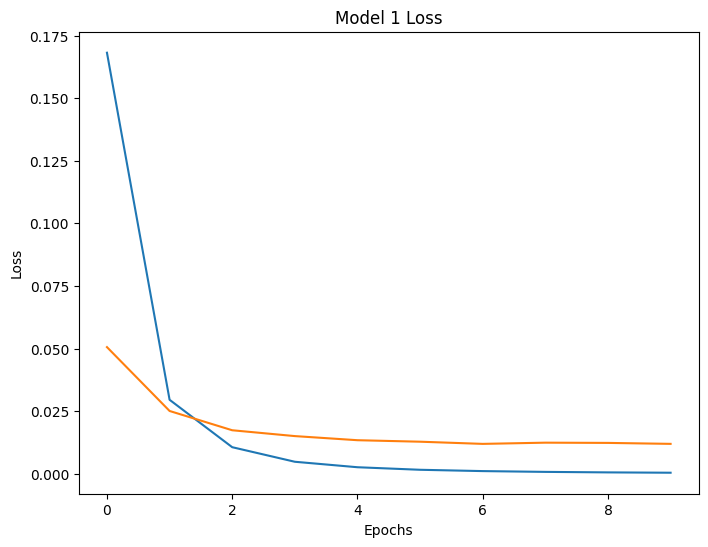

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model 1 Loss')

Text(0.5, 1.0, 'Model 2 Loss')

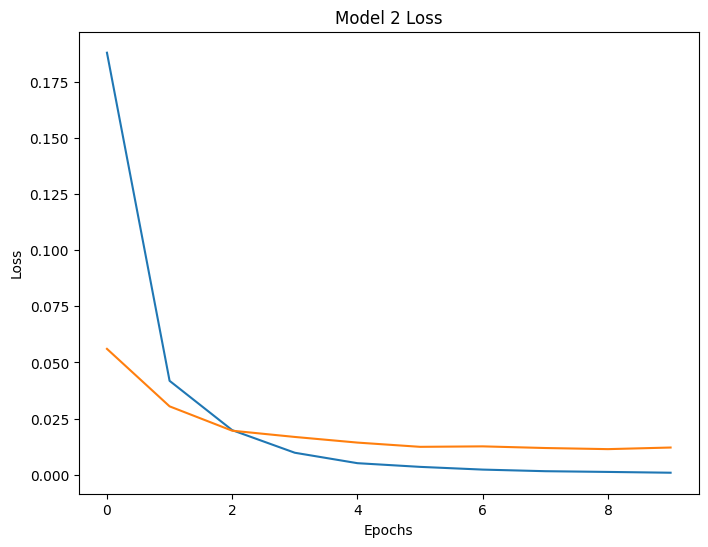

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model 2 Loss')

The training accuracy and validation accuracy reached very high values and remained close together, indicating that the model performed consistently on both training and validation data.

Text(0.5, 1.0, 'Model 1 Accuracy')

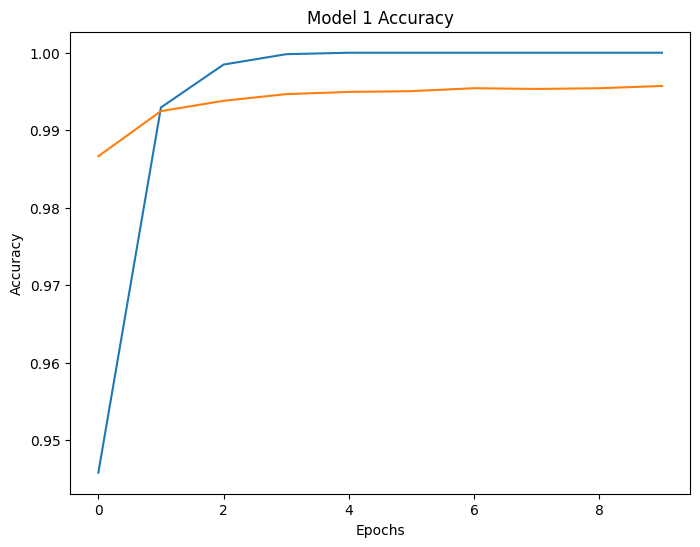

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model 1 Accuracy')

Text(0.5, 1.0, 'Model 2 Accuracy')

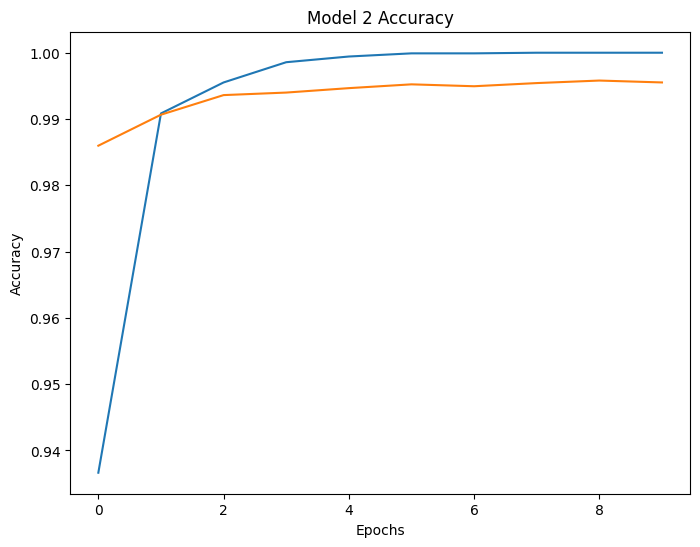

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model 2 Accuracy')

### **Evaluate the neural network using the same metrics as Step 1**

In [ ]:
nn_pred=model2.predict(X_test)

In [ ]:
nn_pred_binary=(nn_pred>0.5).astype(int)
# We used (nn_pred > 0.5).astype(int) to convert the model’s probability outputs (from sigmoid) into final binary classes (0 or 1),
# because the confusion matrix requires discrete predictions instead of probabilities.
print('Neural Network Accuracy:',round(accuracy_score(y_test,nn_pred_binary),2))
print('\nNeural Network Precision:',round(precision_score(y_test,nn_pred_binary),2))
print('\nNeural Network Recall:',round(recall_score(y_test,nn_pred_binary),2))
print('\nNeural Network F1-score:',round(f1_score(y_test,nn_pred_binary),2))

Neural Network Accuracy: 0.98

Neural Network Precision: 1.0

Neural Network Recall: 0.93

Neural Network F1-score: 0.96


### **Add neural network results to the Step 1 summary table.**

In [ ]:
results.append({
    "Model": "Neural Network",
    "Accuracy": 0.98,
    "Precision": 1.0,
    "Recall": 0.92,
    "F1-score": 0.96})
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9989528795811519,
  'Precision': 1.0,
  'Recall': 0.9962546816479401,
  'F1-score': 0.99812382739212},
 {'Model': 'Random Forest',
  'Accuracy': 0.9989528795811519,
  'Precision': 1.0,
  'Recall': 0.9962546816479401,
  'F1-score': 0.99812382739212},
 {'Model': 'KNN',
  'Accuracy': 0.9979057591623036,
  'Precision': 0.9962546816479401,
  'Recall': 0.9962546816479401,
  'F1-score': 0.9962546816479401},
 {'Model': 'Neural Network',
  'Accuracy': 0.98,
  'Precision': 1.0,
  'Recall': 0.92,
  'F1-score': 0.96}]

### **Comparison Between Neural Network and Machine Learning Models.**


*   The neural network made fewer classification errors compared to the machine learning models.
*   The neural network model is far superior to all traditional machine learning models, achieving a perfect score of 100% across all metrics.